# Exercise 12.2c solution


In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


class HodgkinHuxley:
    """A clean implementation of the Hodgkin-Huxley model."""

    def __init__(
        self, C_m=1.0, g_Na=120.0, g_K=36.0, g_L=0.3, E_Na=50.0, E_K=-77.0, E_L=-54.4
    ):
        self.C_m = C_m
        self.g_Na = g_Na
        self.g_K = g_K
        self.g_L = g_L
        self.E_Na = E_Na
        self.E_K = E_K
        self.E_L = E_L

    @staticmethod
    def vtrap(x):
        return np.where(np.abs(x) < 1e-6, 1.0 + x / 2.0, x / (1.0 - np.exp(-x)))

    def alpha_m(self, V):
        return self.vtrap((V + 40) / 10)

    def beta_m(self, V):
        return 4.0 * np.exp(-(V + 65) / 18)

    def alpha_h(self, V):
        return 0.07 * np.exp(-(V + 65) / 20)

    def beta_h(self, V):
        return 1.0 / (1 + np.exp(-(V + 35) / 10))

    def alpha_n(self, V):
        return 0.1 * self.vtrap((V + 55) / 10)

    def beta_n(self, V):
        return 0.125 * np.exp(-(V + 65) / 80)

    def m_inf(self, V):
        return self.alpha_m(V) / (self.alpha_m(V) + self.beta_m(V))

    def h_inf(self, V):
        return self.alpha_h(V) / (self.alpha_h(V) + self.beta_h(V))

    def n_inf(self, V):
        return self.alpha_n(V) / (self.alpha_n(V) + self.beta_n(V))

    def compute_currents(self, V, m, h, n):
        I_Na = self.g_Na * m**3 * h * (V - self.E_Na)
        I_K = self.g_K * n**4 * (V - self.E_K)
        I_L = self.g_L * (V - self.E_L)
        return I_Na, I_K, I_L

    def rhs(self, t, y, I_app_func=None):
        V, m, h, n = y
        I_app = I_app_func(t) if I_app_func else 0.0

        I_Na, I_K, I_L = self.compute_currents(V, m, h, n)

        dVdt = (-I_Na - I_K - I_L + I_app) / self.C_m
        dmdt = self.alpha_m(V) * (1 - m) - self.beta_m(V) * m
        dhdt = self.alpha_h(V) * (1 - h) - self.beta_h(V) * h
        dndt = self.alpha_n(V) * (1 - n) - self.beta_n(V) * n

        return [dVdt, dmdt, dhdt, dndt]

    def steady_state(self, V0=-65.0):
        """Return the steady-state initial conditions at a given resting potential."""
        return [V0, self.m_inf(V0), self.h_inf(V0), self.n_inf(V0)]

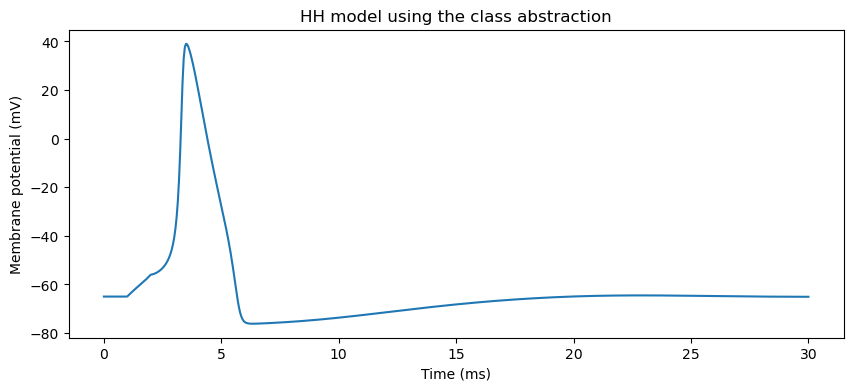

In [2]:
# Example usage
hh = HodgkinHuxley()
y0 = hh.steady_state()


# A brief current pulse
def I_app(t):
    return 10.0 if 1 < t < 2 else 0.0


sol = solve_ivp(hh.rhs, [0, 30], y0, args=(I_app,), max_step=0.05, method="RK45")

plt.figure(figsize=(10, 4))
plt.plot(sol.t, sol.y[0])
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("HH model using the class abstraction")
plt.show()

This class makes it easy to experiment with parameters. For example, to model temperature scaling:

```python
# Scale all rates by Q10 factor for mammalian temperature
hh_warm = HodgkinHuxley()
Q10_factor = 3 ** ((37 - 6.3) / 10)  # ~28.5
# Override rate functions to scale by Q10_factor
```

Or to model a drug that blocks 50% of sodium channels:

```python
hh_drug = HodgkinHuxley(g_Na=60.0)  # half the max conductance
```
